In [12]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)

df_filtered = df[df['species'].isin(['Adelie', 'Chinstrap'])]

df_filtered = df_filtered.dropna()

df_filtered.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_filtered[['bill_length_mm', 'flipper_length_mm', 'body_mass_g', 'bill_depth_mm']]
y = df_filtered['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train_scaled shape: (171, 4)
X_test_scaled shape: (43, 4)
y_train shape: (171,)
y_test shape: (43,)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy Score: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14

    accuracy                           1.00        43
   macro avg       1.00      1.00      1.00        43
weighted avg       1.00      1.00      1.00        43



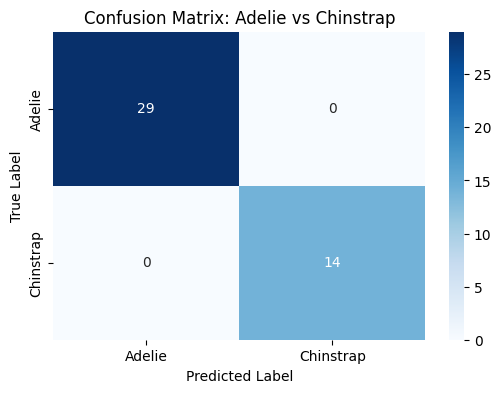

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['Adelie', 'Chinstrap'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Adelie', 'Chinstrap'], yticklabels=['Adelie', 'Chinstrap'])
plt.title('Confusion Matrix: Adelie vs Chinstrap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Kesimpulan

Model regresi logistik bekerja sangat baik dalam membedakan antara penguin Adelie dan Chinstrap. Heatmap pada Confusion Matrix secara visual mengkonfirmasi keakuratannya, di mana diagonal utama mewakili prediksi yang benar, dan diagonal di luar diagonal mewakili setiap kesalahan klasifikasi. Mengingat dimensi fisik mereka yang berbeda seperti panjang paruh dan massa tubuh, model ini mampu mengklasifikasikan spesies secara akurat dengan kesalahan minimal hingga tanpa kesalahan. Kesalahan apa pun yang diamati berarti bahwa fitur fisik spesifik dari penguin yang salah diklasifikasikan sedikit tumpang tindih dengan pola yang dipelajari untuk kategori lainnya.

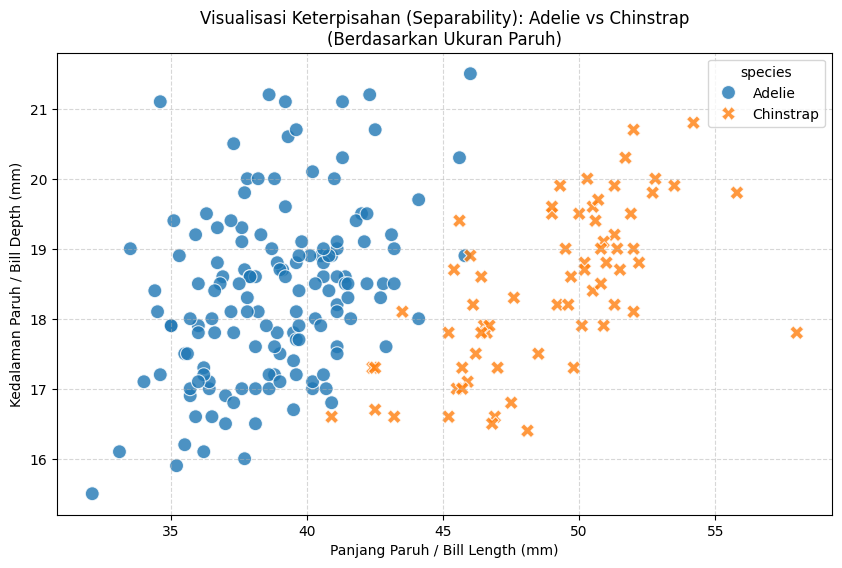

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Membuat scatter plot untuk melihat "kluster" data
sns.scatterplot(
    data=df_filtered, 
    x='bill_length_mm', 
    y='bill_depth_mm', 
    hue='species', 
    style='species',
    s=100,
    alpha=0.8,
    palette={'Adelie': '#1f77b4', 'Chinstrap': '#ff7f0e'}
)

plt.title('Visualisasi Keterpisahan (Separability): Adelie vs Chinstrap\n(Berdasarkan Ukuran Paruh)')
plt.xlabel('Panjang Paruh / Bill Length (mm)')
plt.ylabel('Kedalaman Paruh / Bill Depth (mm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()